# EDA — Vibration Signal Evolution Across Bearing Lifecycle

**Issue #9 (M1-EDA):** visualize how the raw vibration signal and its derived statistics
(RMS, kurtosis) evolve across a bearing's run-to-failure life, for one bearing per experiment
set (`1st_test`, `2nd_test`, `3rd_test`) — to build intuition before defining health-state
thresholds in Issue #10.

Dataset background and channel layout: `data/README.md` and
`data/raw/Readme Document for IMS Bearing Data.pdf`. Each file is a 1-second, 20,480-point
snapshot at 20 kHz, taken roughly every 10 minutes across the bearing's life.

For each experiment we pick the bearing that the NASA documentation records as the one that
actually failed, so the "before/after" contrast in the plots corresponds to a real, documented
failure rather than an arbitrary channel:

| Experiment | Bearing tracked | Channel | Documented failure mode |
|---|---|---|---|
| `1st_test` | Bearing 3 | Ch 5 (of 8) | inner race defect |
| `2nd_test` | Bearing 1 | Ch 1 (of 4) | outer race failure |
| `3rd_test` | Bearing 3 | Ch 3 (of 4) | outer race failure |


In [1]:
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

DATA_DIR = Path("../data/raw")
CACHE_DIR = Path("../data/processed")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

FS = 20_000        # sampling rate, Hz
N_POINTS = 20_480   # points per 1-second snapshot

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Setup

Filenames are timestamps in `YYYY.MM.DD.HH.MM.SS` format, so a plain lexicographic sort of the
filenames already puts each experiment's snapshots in chronological order — no separate parsing
needed for ordering, only for turning a filename into a `datetime` for plotting.

Colors are assigned per experiment and held constant across every figure below (Okabe-Ito
colorblind-safe qualitative set), so the same experiment is always the same color.


In [2]:
def list_snapshot_files(test_dir: Path) -> list[Path]:
    """Snapshot filenames are timestamps, so lexicographic sort == chronological order."""
    return sorted(test_dir.iterdir(), key=lambda p: p.name)


def parse_timestamp(path: Path) -> datetime:
    return datetime.strptime(path.name, "%Y.%m.%d.%H.%M.%S")


def load_channel(path: Path, channel_idx: int) -> np.ndarray:
    """Read a single channel column from a snapshot file without loading the rest."""
    return (
        pd.read_csv(path, sep="\t", header=None, usecols=[channel_idx], dtype=np.float32)
        .iloc[:, 0]
        .to_numpy()
    )


EXPERIMENTS = {
    "1st_test": {
        "dir": DATA_DIR / "1st_test",
        "channel_idx": 4,  # Bearing 3, Ch 5 (0-based column index)
        "bearing_label": "Bearing 3, Ch 5",
        "failure_mode": "inner race defect",
        "color": "#0072B2",  # Okabe-Ito blue
    },
    "2nd_test": {
        "dir": DATA_DIR / "2nd_test",
        "channel_idx": 0,  # Bearing 1, Ch 1
        "bearing_label": "Bearing 1, Ch 1",
        "failure_mode": "outer race failure",
        "color": "#D55E00",  # Okabe-Ito vermillion
    },
    "3rd_test": {
        "dir": DATA_DIR / "3rd_test",
        "channel_idx": 2,  # Bearing 3, Ch 3
        "bearing_label": "Bearing 3, Ch 3",
        "failure_mode": "outer race failure",
        "color": "#009E73",  # Okabe-Ito green
    },
}

for name, cfg in EXPERIMENTS.items():
    files = list_snapshot_files(cfg["dir"])
    print(f"{name}: {len(files)} snapshots, {files[0].name} -> {files[-1].name}")


1st_test: 2156 snapshots, 2003.10.22.12.06.24 -> 2003.11.25.23.39.56
2nd_test: 984 snapshots, 2004.02.12.10.32.39 -> 2004.02.19.06.22.39
3rd_test: 6324 snapshots, 2004.03.04.09.27.46 -> 2004.04.18.02.42.55


## 1. Raw vibration signal across the bearing's lifecycle

Rather than overlay every one of the ~1,000-6,000 snapshots (unreadable), each experiment shows
6 snapshots evenly spaced across the run — from the start of the test to the last recorded file
— for the bearing that ultimately failed. The y-axis is held fixed within each experiment so
amplitude growth (or lack of it) between the panels is directly comparable.


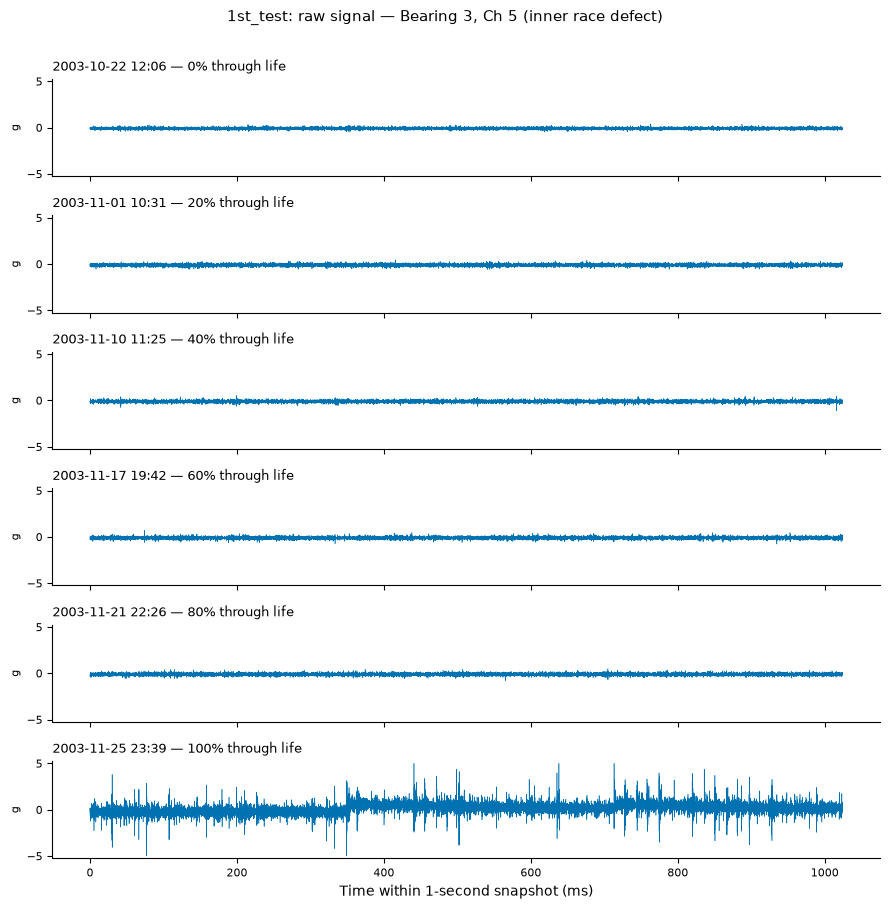

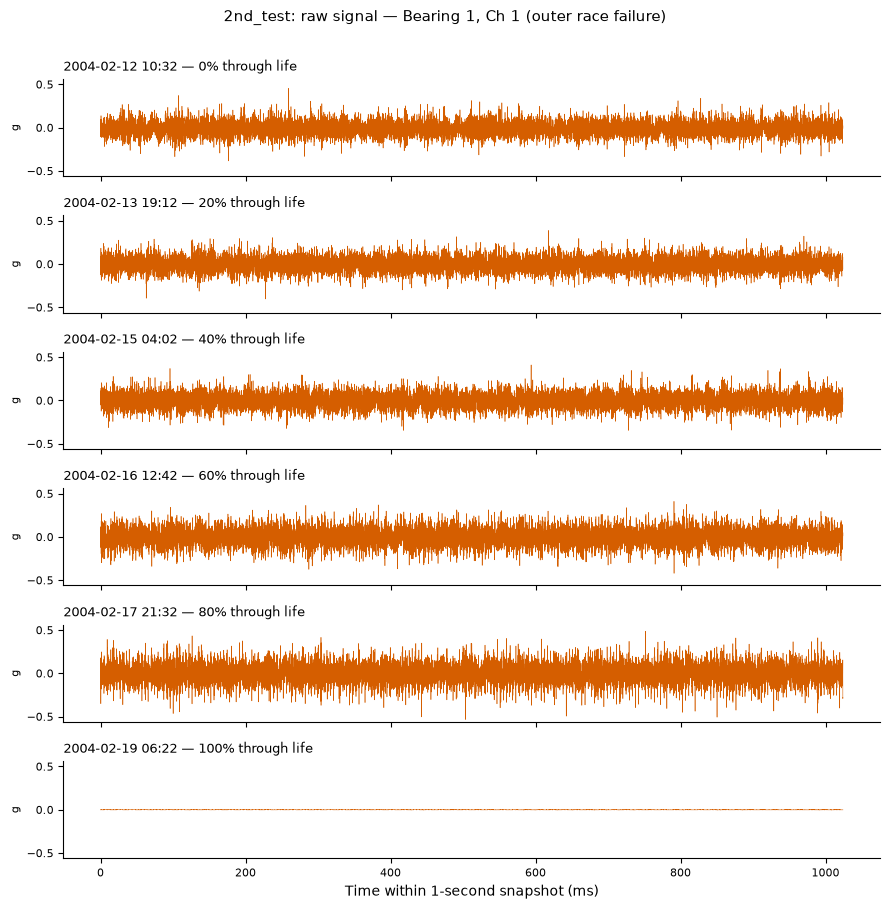

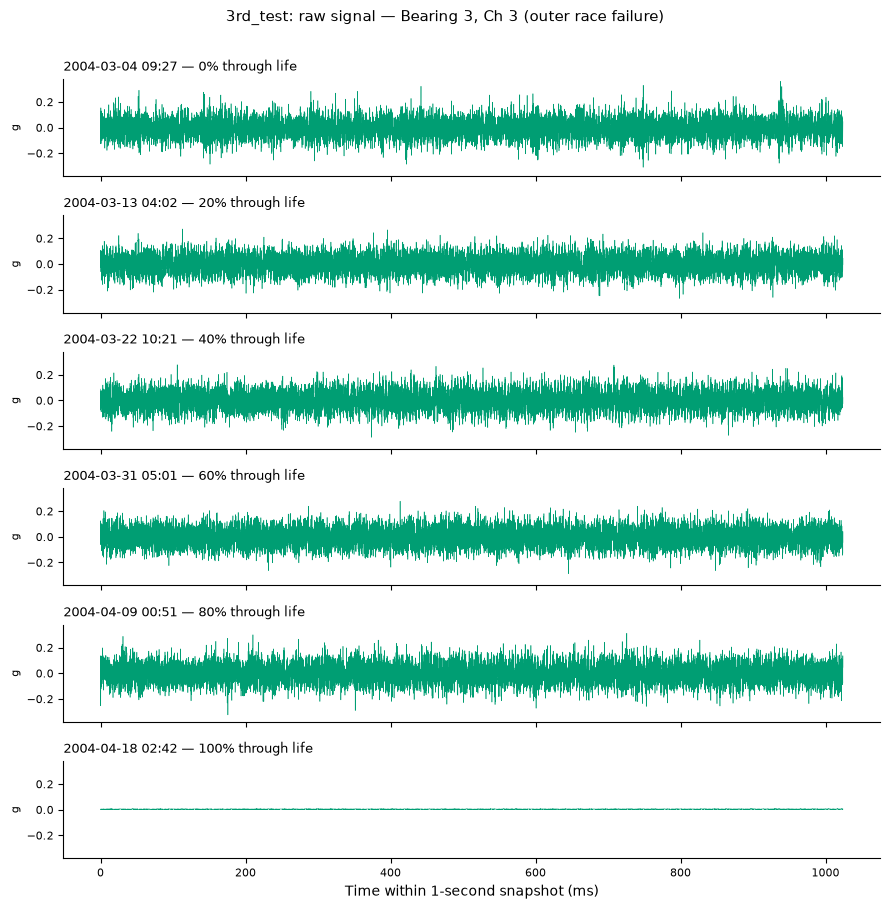

In [3]:
def plot_raw_signal_evolution(name: str, cfg: dict, n_snapshots: int = 6):
    files = list_snapshot_files(cfg["dir"])
    idxs = np.linspace(0, len(files) - 1, n_snapshots, dtype=int)
    signals = [load_channel(files[i], cfg["channel_idx"]) for i in idxs]
    y_max = max(np.abs(s).max() for s in signals) * 1.05
    t_ms = np.arange(N_POINTS) / FS * 1000  # ms within the 1-second snapshot

    fig, axes = plt.subplots(
        n_snapshots, 1, figsize=(9, 1.5 * n_snapshots), sharex=True, sharey=True
    )
    for ax, i, sig in zip(axes, idxs, signals):
        pct = i / (len(files) - 1) * 100
        ts = parse_timestamp(files[i])
        ax.plot(t_ms, sig, color=cfg["color"], linewidth=0.4)
        ax.set_ylim(-y_max, y_max)
        ax.set_ylabel("g", fontsize=8)
        ax.set_title(f"{ts:%Y-%m-%d %H:%M} \u2014 {pct:.0f}% through life", fontsize=9, loc="left")
        ax.tick_params(labelsize=8)

    axes[-1].set_xlabel("Time within 1-second snapshot (ms)")
    fig.suptitle(
        f"{name}: raw signal \u2014 {cfg['bearing_label']} ({cfg['failure_mode']})",
        y=1.005, fontsize=11,
    )
    fig.tight_layout()
    plt.show()


for name, cfg in EXPERIMENTS.items():
    plot_raw_signal_evolution(name, cfg)


## 2. RMS and kurtosis trend over the full run-to-failure life

RMS (signal energy / overall vibration magnitude) and kurtosis (spikiness / impulsiveness of the
signal — a Gaussian signal has kurtosis 3, shown as a reference line) are computed per snapshot
file, across **every** file in the experiment, so the trend covers the complete run-to-failure
history rather than a sample of it.

This is the most expensive cell in the notebook (~9,400 single-column file reads total across
the three experiments). Results are cached to `data/processed/` (gitignored, like the rest of
`data/`) so re-running the notebook after the first pass is instant.


In [4]:
def compute_lifetime_stats(name: str, cfg: dict, force: bool = False) -> pd.DataFrame:
    cache_path = CACHE_DIR / f"{name}_rms_kurtosis.csv"
    if cache_path.exists() and not force:
        return pd.read_csv(cache_path, parse_dates=["timestamp"])

    files = list_snapshot_files(cfg["dir"])
    records = []
    for i, f in enumerate(files):
        sig = load_channel(f, cfg["channel_idx"])
        records.append(
            {
                "timestamp": parse_timestamp(f),
                "file_index": i,
                "rms": float(np.sqrt(np.mean(sig**2))),
                "kurtosis": float(kurtosis(sig, fisher=False)),  # standard kurtosis, Gaussian = 3
            }
        )
        if (i + 1) % 1000 == 0:
            print(f"  {name}: {i + 1}/{len(files)} files processed")

    df = pd.DataFrame(records)
    df.to_csv(cache_path, index=False)
    return df


stats = {name: compute_lifetime_stats(name, cfg) for name, cfg in EXPERIMENTS.items()}


  1st_test: 1000/2156 files processed


  1st_test: 2000/2156 files processed


  3rd_test: 1000/6324 files processed


  3rd_test: 2000/6324 files processed


  3rd_test: 3000/6324 files processed


  3rd_test: 4000/6324 files processed


  3rd_test: 5000/6324 files processed


  3rd_test: 6000/6324 files processed


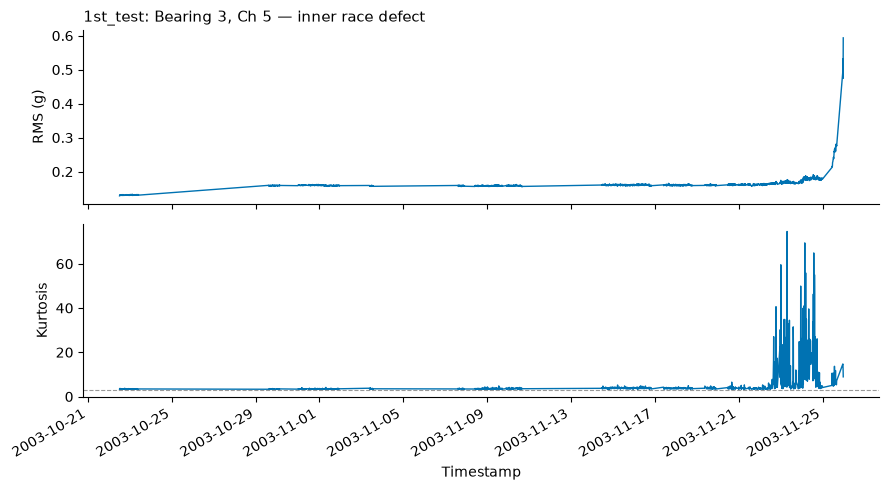

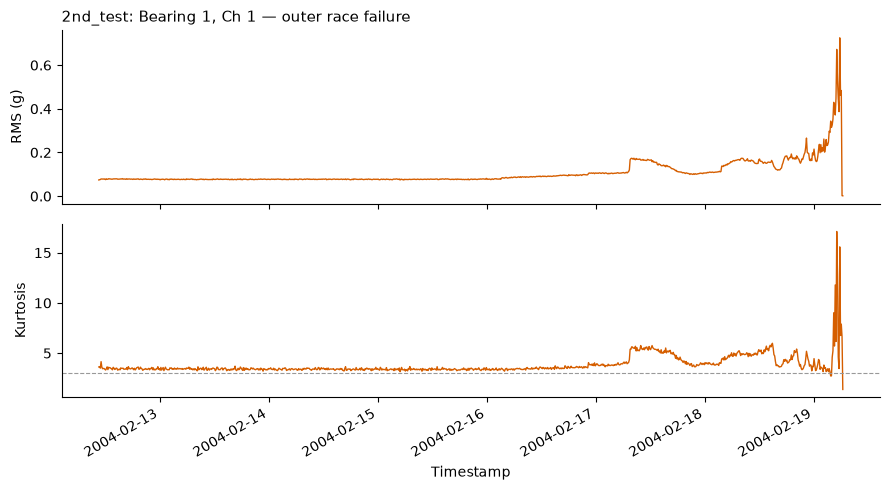

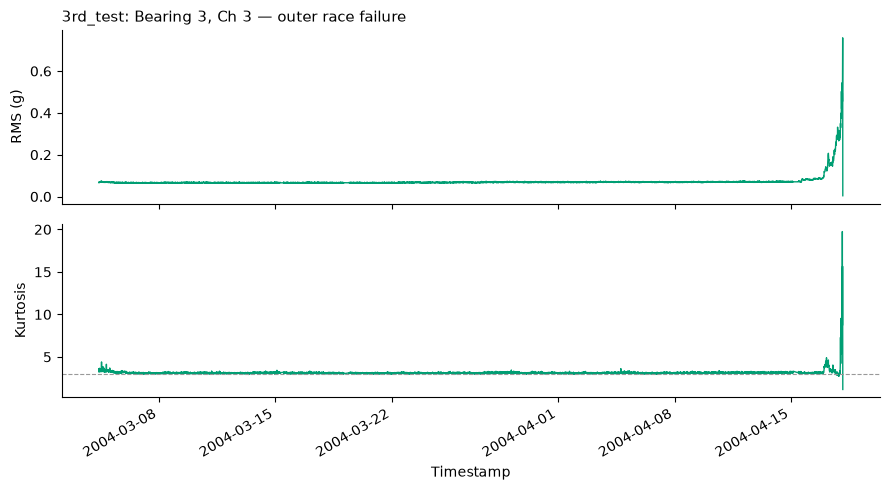

In [5]:
def plot_lifetime_trend(name: str, cfg: dict, df: pd.DataFrame):
    fig, (ax_rms, ax_kurt) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

    ax_rms.plot(df["timestamp"], df["rms"], color=cfg["color"], linewidth=1)
    ax_rms.set_ylabel("RMS (g)")
    ax_rms.set_title(
        f"{name}: {cfg['bearing_label']} \u2014 {cfg['failure_mode']}", loc="left", fontsize=11
    )

    ax_kurt.plot(df["timestamp"], df["kurtosis"], color=cfg["color"], linewidth=1)
    ax_kurt.axhline(3, color="0.6", linewidth=0.8, linestyle="--")
    ax_kurt.set_ylabel("Kurtosis")
    ax_kurt.set_xlabel("Timestamp")

    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


for name, cfg in EXPERIMENTS.items():
    plot_lifetime_trend(name, cfg, stats[name])


## 3. Cross-experiment comparison

The three experiments differ in absolute duration (`1st_test` runs ~5 weeks, `2nd_test` ~1 week,
`3rd_test` ~6 weeks), so comparing them directly requires normalizing the x-axis to **% of life**
rather than wall-clock time.


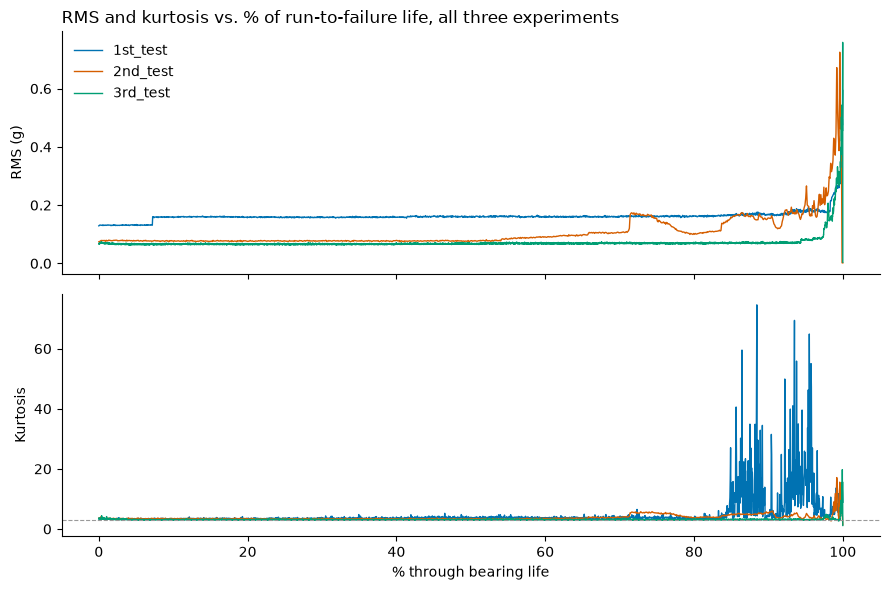

In [6]:
fig, (ax_rms, ax_kurt) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for name, cfg in EXPERIMENTS.items():
    df = stats[name]
    pct_life = df["file_index"] / (len(df) - 1) * 100
    ax_rms.plot(pct_life, df["rms"], color=cfg["color"], linewidth=1, label=name)
    ax_kurt.plot(pct_life, df["kurtosis"], color=cfg["color"], linewidth=1, label=name)

ax_kurt.axhline(3, color="0.6", linewidth=0.8, linestyle="--")
ax_rms.set_ylabel("RMS (g)")
ax_kurt.set_ylabel("Kurtosis")
ax_kurt.set_xlabel("% through bearing life")
ax_rms.set_title("RMS and kurtosis vs. % of run-to-failure life, all three experiments", loc="left")
ax_rms.legend(frameon=False)
fig.tight_layout()
plt.show()


## Observations

**A degradation trend is clearly visible in RMS (and, more noisily, in kurtosis) in all three
experiments — but the *timing* of onset differs a lot, which matters for Issue #10.**

Baseline (first 50 files) vs. peak RMS, and where a sustained rise above 1.3x baseline first
appears (as a rough "Normal → Degrading" onset marker):

| Experiment | Baseline RMS | Peak RMS | Peak / baseline | Onset of sustained rise | Peak kurtosis |
|---|---|---|---|---|---|
| `1st_test` (Bearing 3, inner race) | 0.131 g | 0.594 g | ~4.5x | ~88% through life (2003-11-23) | 74.6 |
| `2nd_test` (Bearing 1, outer race) | 0.078 g | 0.725 g | ~9.3x | ~66% through life (2004-02-16) | 17.1 |
| `3rd_test` (Bearing 3, outer race) | 0.070 g | 0.759 g | ~10.9x | ~97% through life (2004-04-16) | 19.7 |

- **`1st_test`:** flat, low-noise baseline (kurtosis ~3.4, close to Gaussian) for most of the run,
  then a rise beginning around 88% through life, reaching a final RMS ~4.5x baseline. Kurtosis is
  far spikier here than in the other two experiments (peak 74.6 vs. ~17-20) — consistent with two
  failing bearings (inner race + roller element) producing sharp, impulsive impacts rather than a
  smooth amplitude ramp. Both signals agree: a moderately early-onset, high-impulsiveness failure.
- **`2nd_test`:** the earliest relative onset of the three — sustained rise starts around 66%
  through its (much shorter, ~1 week) life, so roughly the final third of the run reads as
  "Degrading." RMS reaches the highest baseline-relative peak of the three (~9.3x). The kurtosis
  trend tracks RMS reasonably closely here.
- **`3rd_test`:** the opposite extreme — despite being the longest run (~6 weeks, 6,324 files),
  RMS doesn't sustain above 1.3x baseline until ~97% through life. Over 96% of this experiment's
  life reads as flat "Normal," with the entire degradation-to-failure trajectory compressed into
  the last day or two. This is the experiment where a threshold expressed as "% of a fixed
  historical run length" would be least generalizable — a threshold on the statistic itself
  (e.g., multiple of baseline RMS) is more robust here.

**Data quality note relevant to Issue #10:** the final recorded snapshot of both `2nd_test` and
`3rd_test` collapses to near-zero RMS (0.0015 g and 0.0040 g respectively — far below even their
baseline), while `1st_test`'s final snapshot stays high (0.594 g, its peak). This is almost
certainly the test rig automatically stopping the shaft once the outer-race failure was detected
(sets 2 and 3 both document outer-race failure as the stopping condition), not a return to
health. Whatever labeling logic Issue #10 defines should treat each experiment's last file (or
last few) as a rig-stopped artifact rather than literal sensor data — including it naively would
corrupt a "Critical" class boundary defined on raw RMS.

**Cross-experiment takeaway:** all three experiments spend the large majority of their
run-to-failure life in a flat, low-RMS "Normal" baseline, with a comparatively short,
sharply-rising tail before failure — supporting the PRD's 3-class (Normal / Degrading / Critical)
framing over a linear/continuous trend. RMS is the cleaner, more monotonic signal of the two for
defining thresholds; kurtosis is a useful corroborating signal (especially for the impulsive
`1st_test` failure) but has a much larger and noisier dynamic range, particularly for the two
outer-race failures. Because onset ranges from ~66% to ~97% through life depending on the
experiment, thresholds for Issue #10 should be defined relative to each bearing's own baseline
statistics rather than a fixed elapsed-time or file-count cutoff.
